# WM-811K Wafer Map — Vision Transformer

Load the dataset, filter out unknown failure types, split via `trianTestLabel`, and train a small Vision Transformer (ViT) from scratch.

In [1]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from scipy.ndimage import zoom
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

## 1. Load the data

In [2]:
import pickle
import sys

# Patch old pandas module paths for compatibility
# The pickle was saved with pandas < 0.20 which used pandas.indexes.*
_compat_map = {
    'pandas.indexes':         'pandas.core.indexes',
    'pandas.indexes.base':    'pandas.core.indexes.base',
    'pandas.indexes.numeric': 'pandas.core.indexes.base',
    'pandas.indexes.range':   'pandas.core.indexes.range_',
    'pandas.indexes.multi':   'pandas.core.indexes.multi',
    'pandas.indexes.frozen':  'pandas.core.indexes.frozen',
}

for old, new in _compat_map.items():
    try:
        sys.modules[old] = __import__(new, fromlist=[''])
    except ImportError:
        pass

class _CompatUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        for old, new in _compat_map.items():
            if module.startswith(old):
                module = module.replace(old, new, 1)
                break
        return super().find_class(module, name)

with open("./Data/LSWMD.pkl", "rb") as f:
    try:
        df = pickle.load(f, encoding='latin1')
    except (ModuleNotFoundError, ImportError):
        f.seek(0)
        df = _CompatUnpickler(f)
        df.encoding = 'latin1'
        df = df.load()

print(f"Shape: {df.shape}")
df.head()

/tmp/ipykernel_112771/2994757470.py:31: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  df = pickle.load(f, encoding='latin1')


Shape: (811457, 6)


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


## 2. Extract labels and filter out unknown failure types

The `failureType` column is stored as a nested array. Rows with an empty array (no label) or `'unknown'` are dropped — keeping only the 9 named defect classes plus `none`.

In [3]:
def extract_label(x):
    if isinstance(x, (list, np.ndarray)):
        flat = np.array(x).flatten()
        if len(flat) > 0:
            return str(flat[0])
    if isinstance(x, str):
        return x
    return "unknown"

df['failure_label'] = df['failureType'].apply(extract_label)

# Drop unlabeled rows
df_labeled = df[~df['failure_label'].isin(['unknown', ''])].reset_index(drop=True)

print(f"Before filter: {len(df):,}")
print(f"After filter:  {len(df_labeled):,}")
print(f"\nClass counts:")
print(df_labeled['failure_label'].value_counts())

Before filter: 811,457
After filter:  172,950

Class counts:
failure_label
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


## 3. Train / val / test split

Test set comes from `trianTestLabel == 'Test'` (the dataset's pre-assigned holdout). The `Training` rows are split 90 / 10 (stratified by class) into train and validation.

In [4]:
classes = sorted(df_labeled['failure_label'].unique().tolist())
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
NUM_CLASSES = len(classes)
print(f"{NUM_CLASSES} classes: {classes}")

df_labeled['label_idx'] = df_labeled['failure_label'].map(class_to_idx)

# 60/20/20 stratified: first carve off 20% test, then split the remaining 80% into 60/20 (i.e. 0.25 of 0.8).
y = df_labeled['label_idx'].values
idx_all = np.arange(len(df_labeled))

idx_trainval, idx_test = train_test_split(
    idx_all, test_size=0.20, stratify=y, random_state=SEED
)
idx_train, idx_val = train_test_split(
    idx_trainval, test_size=0.25, stratify=y[idx_trainval], random_state=SEED
)

print(f"\nTrain: {len(idx_train):,}  ({len(idx_train)/len(idx_all):.1%})")
print(f"Val:   {len(idx_val):,}  ({len(idx_val)/len(idx_all):.1%})")
print(f"Test:  {len(idx_test):,}  ({len(idx_test)/len(idx_all):.1%})")

# Verify class proportions match across splits
prop_table = pd.DataFrame({
    'all':   df_labeled['failure_label'].value_counts(normalize=True),
    'train': df_labeled.iloc[idx_train]['failure_label'].value_counts(normalize=True),
    'val':   df_labeled.iloc[idx_val]['failure_label'].value_counts(normalize=True),
    'test':  df_labeled.iloc[idx_test]['failure_label'].value_counts(normalize=True),
}).fillna(0).round(4)
print("\nClass proportions per split:")
prop_table

9 classes: ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch', 'none']

Train: 103,770  (60.0%)
Val:   34,590  (20.0%)
Test:  34,590  (20.0%)

Class proportions per split:


,all,train,val,test
failure_label,,,,
none,0.8524,0.8525,0.8524,0.8524
Edge-Ring,0.0560,0.0560,0.0560,0.0560
Edge-Loc,0.0300,0.0300,0.0300,0.0300
Center,0.0248,0.0248,0.0248,0.0248
Loc,0.0208,0.0208,0.0208,0.0208
Scratch,0.0069,0.0069,0.0069,0.0069
Random,0.0050,0.0050,0.0050,0.0050
Donut,0.0032,0.0032,0.0032,0.0032
Near-full,0.0009,0.0009,0.0009,0.0009


## 4. PyTorch `Dataset`

Training maps are **pre-resized** to `IMG_SIZE × IMG_SIZE` with nearest-neighbor (preserves the discrete 0/1/2 codes) and kept in memory. Every class is brought to exactly **20 000 samples**:

- **Classes with ≥ 20 000 samples** (`none`, ~88 k in train): randomly subsampled to 20 000 without replacement — no augmentation needed.
- **Classes with < 20 000 samples**: augmented via random flips (none / h-flip / v-flip / hv-flip) until each reaches 20 000. Within each expansion cycle the full pool of `(image, flip_variant)` pairs is shuffled before any pair repeats.

Validation and test stay deterministic (no augmentation).

In [5]:
IMG_SIZE = 64

# ------------------------------------------------------------------
# Pre-resize training maps (eager so augmentation logic stays fast)
# ------------------------------------------------------------------
def _resize(wmap, size):
    wmap = np.asarray(wmap)
    if wmap.ndim < 2 or wmap.shape[0] == 0 or wmap.shape[1] == 0:
        return np.zeros((size, size), dtype=np.float32)
    h, w = wmap.shape
    return zoom(wmap, (size / h, size / w), order=0).astype(np.float32)

print("Pre-resizing training maps to 64×64 …", end="", flush=True)
train_maps_64 = np.stack([
    _resize(m, IMG_SIZE) / 2.0
    for m in df_labeled['waferMap'].values[idx_train]
])                                              # (N_train, 64, 64), values in {0, 0.5, 1.0}
train_labels_raw = df_labeled['label_idx'].values[idx_train].astype(np.int64)
print(f" done — shape: {train_maps_64.shape}")


# ------------------------------------------------------------------
# Dataset
# ------------------------------------------------------------------
class WaferMapDataset(Dataset):
    """
    Train mode  — pass `maps` (N_orig,H,W float32), `src_indices`, `labels`,
                  and `flip_codes`.  src_indices maps each augmented sample back
                  to its original map; flip is then applied on top.
    Val/test    — pass `df` + `indices`; lazy resize in __getitem__.

    flip_codes: int8 bit-flags  0=none  1=hflip  2=vflip  3=both.
    """
    def __init__(self, df=None, indices=None, img_size=IMG_SIZE,
                 maps=None, src_indices=None, labels=None, flip_codes=None):
        if maps is not None:
            self.maps        = maps
            self.src_indices = src_indices          # shape (N_aug,), values in [0, N_orig)
            self.labels      = labels.astype(np.int64)
            self.flip_codes  = flip_codes
            self._lazy       = False
        else:
            self.raw_maps = df['waferMap'].values[indices]
            self.labels   = df['label_idx'].values[indices].astype(np.int64)
            self.img_size = img_size
            self._lazy    = True

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        if self._lazy:
            wmap = _resize(self.raw_maps[i], self.img_size) / 2.0
        else:
            wmap = self.maps[self.src_indices[i]].copy()   # look up original map
            fc   = int(self.flip_codes[i])
            if fc & 1:
                wmap = wmap[:, ::-1]    # horizontal flip
            if fc & 2:
                wmap = wmap[::-1, :]    # vertical flip
            wmap = np.ascontiguousarray(wmap)
        x = torch.from_numpy(wmap).unsqueeze(0)           # (1, H, W)
        y = torch.tensor(self.labels[i], dtype=torch.long)
        return x, y

val_ds  = WaferMapDataset(df=df_labeled, indices=idx_val,  img_size=IMG_SIZE)
test_ds = WaferMapDataset(df=df_labeled, indices=idx_test, img_size=IMG_SIZE)

x_probe, y_probe = val_ds[0]
print(f"val sample — x: {tuple(x_probe.shape)}  dtype={x_probe.dtype}  "
      f"min={x_probe.min():.2f} max={x_probe.max():.2f}")
print(f"            y: {y_probe.item()} ({idx_to_class[y_probe.item()]})")

Pre-resizing training maps to 64×64 … done — shape: (103770, 64, 64)
val sample — x: (1, 64, 64)  dtype=torch.float32  min=0.00 max=1.00
            y: 8 (none)


## 5. `DataLoader`s

In [6]:
BATCH_SIZE  = 64
NUM_WORKERS = 0
AUG_TARGET  = 20_000   # samples per class after balancing

# ------------------------------------------------------------------
# Augmentation plan: bring every class to exactly AUG_TARGET samples
# ------------------------------------------------------------------
def make_aug_plan(labels, seed=SEED, target=AUG_TARGET):
    """
    Return (src_indices, flip_codes) of length NUM_CLASSES * target.

    src_indices: positions into the original training array (values in [0, N_train)).
    flip_codes:  int8 bit-flags — 0=none  1=hflip  2=vflip  3=hvflip.

    - Classes with >= target samples: randomly subsampled without replacement.
    - Classes with <  target samples: augmented via flip variants. Within each
      cycle the full (image, variant) pool is shuffled before any pair repeats.
    """
    rng = np.random.default_rng(seed)
    class_counts = np.bincount(labels)
    all_src, all_flip = [], []
    for cls in range(len(class_counts)):
        cls_idx = np.where(labels == cls)[0]
        n = len(cls_idx)
        if n >= target:
            chosen = rng.choice(cls_idx, size=target, replace=False)
            all_src.append(chosen)
            all_flip.append(np.zeros(target, dtype=np.int8))
        else:
            pool_src  = np.tile(cls_idx, 4)
            pool_flip = np.repeat(np.arange(4, dtype=np.int8), n)
            perm = rng.permutation(len(pool_src))
            pool_src, pool_flip = pool_src[perm], pool_flip[perm]
            reps = -(-target // len(pool_src))      # ceiling division
            src  = np.tile(pool_src,  reps)[:target]
            flip = np.tile(pool_flip, reps)[:target]
            all_src.append(src)
            all_flip.append(flip)
    src  = np.concatenate(all_src)
    flip = np.concatenate(all_flip)
    perm = rng.permutation(len(src))
    return src[perm], flip[perm]

aug_src, aug_flip = make_aug_plan(train_labels_raw)
aug_labels = train_labels_raw[aug_src]

# ---- class-balance report ----------------------------------------
orig_counts = np.bincount(train_labels_raw, minlength=NUM_CLASSES)
aug_counts  = np.bincount(aug_labels,       minlength=NUM_CLASSES)
tot_b, tot_a = orig_counts.sum(), aug_counts.sum()

print(f"Augmented training set: {tot_a:,} samples  ({tot_a / tot_b:.2f}× original)\n")
print(f"{'class':12s} {'before':>10s} {'after':>10s} {'note':>16s}")
print('-' * 52)
for i in range(NUM_CLASSES):
    note = 'subsampled' if orig_counts[i] >= AUG_TARGET else 'flip-augmented'
    print(f"{idx_to_class[i]:12s} {orig_counts[i]:>10,d} {aug_counts[i]:>10,d}  {note}")
print('-' * 52)
print(f"{'total':12s} {tot_b:>10,d} {tot_a:>10,d}")

# ------------------------------------------------------------------
# Datasets + DataLoaders
# ------------------------------------------------------------------
train_ds = WaferMapDataset(maps=train_maps_64, src_indices=aug_src,
                           labels=aug_labels, flip_codes=aug_flip)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS)

xb, yb = next(iter(train_loader))
print(f"\nbatch x: {tuple(xb.shape)}  dtype={xb.dtype}")
print(f"batch y: {tuple(yb.shape)}  dtype={yb.dtype}")

Augmented training set: 180,000 samples  (1.73× original)

class            before      after             note
----------------------------------------------------
Center            2,576     20,000  flip-augmented
Donut               333     20,000  flip-augmented
Edge-Loc          3,113     20,000  flip-augmented
Edge-Ring         5,808     20,000  flip-augmented
Loc               2,156     20,000  flip-augmented
Near-full            89     20,000  flip-augmented
Random              520     20,000  flip-augmented
Scratch             716     20,000  flip-augmented
none             88,459     20,000  subsampled
----------------------------------------------------
total           103,770    180,000

batch x: (64, 1, 64, 64)  dtype=torch.float32
batch y: (64,)  dtype=torch.int64


## 6. Model 3 — Vision Transformer

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F


def drop_path(x, drop_prob: float = 0.0, training: bool = False):
    if drop_prob == 0.0 or not training:
        return x
    keep = 1 - drop_prob
    shape = (x.shape[0],) + (1,) * (x.ndim - 1)
    noise = torch.empty(shape, dtype=x.dtype, device=x.device).bernoulli_(keep).div_(keep)
    return x * noise


class DropPath(nn.Module):
    def __init__(self, drop_prob: float = 0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        return drop_path(x, self.drop_prob, self.training)


class PatchEmbed(nn.Module):
    def __init__(self, img_size=64, patch_size=8, in_channels=1, embed_dim=128):
        super().__init__()
        assert img_size % patch_size == 0
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Sequential(
            nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size),
            nn.BatchNorm2d(embed_dim),
        )

    def forward(self, x):
        return self.proj(x).flatten(2).transpose(1, 2)  # (B, N, E)


class Block(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio=2.0,
                 attn_drop=0.1, proj_drop=0.2, drop_path_rate=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = nn.MultiheadAttention(embed_dim, num_heads,
                                            dropout=attn_drop, batch_first=True)
        self.attn_drop = nn.Dropout(proj_drop)

        self.norm2 = nn.LayerNorm(embed_dim)
        hidden = int(embed_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden),
            nn.GELU(),
            nn.Dropout(proj_drop),
            nn.Linear(hidden, embed_dim),
            nn.Dropout(proj_drop),
        )
        self.drop_path = DropPath(drop_path_rate) if drop_path_rate > 0 else nn.Identity()

    def forward(self, x):
        h, _ = self.attn(*[self.norm1(x)] * 3, need_weights=False)
        x = x + self.drop_path(self.attn_drop(h))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x


class Model3(nn.Module):
    """
    Anti-overfit ViT for 64x64 single-channel wafer maps.

    Regularization stack:
      - BatchNorm2d after patch projection
      - pos_drop (embedding dropout)         0.15
      - attn dropout (inside MHA)            0.10
      - attn output dropout                  0.20
      - MLP dropout (x2)                     0.20
      - stochastic depth, linear 0→0.20
      - head: BN → Dropout(0.4) → Linear
    """
    def __init__(
        self,
        num_classes: int = 9,
        in_channels: int = 1,
        img_size: int = 64,
        patch_size: int = 8,
        embed_dim: int = 128,
        depth: int = 4,
        num_heads: int = 4,
        mlp_ratio: float = 2.0,
        drop_rate: float = 0.15,
        attn_drop_rate: float = 0.10,
        proj_drop_rate: float = 0.20,
        drop_path_rate: float = 0.20,
        head_drop_rate: float = 0.40,
    ):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches

        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, embed_dim))
        self.pos_drop  = nn.Dropout(drop_rate)

        dpr = [r.item() for r in torch.linspace(0, drop_path_rate, depth)]
        self.blocks = nn.ModuleList([
            Block(embed_dim, num_heads, mlp_ratio,
                  attn_drop=attn_drop_rate,
                  proj_drop=proj_drop_rate,
                  drop_path_rate=dpr[i])
            for i in range(depth)
        ])

        self.norm = nn.LayerNorm(embed_dim)

        self.head = nn.Sequential(
            nn.BatchNorm1d(embed_dim),
            nn.Dropout(head_drop_rate),
            nn.Linear(embed_dim, num_classes),
        )

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.patch_embed(x)
        x = self.pos_drop(x + self.pos_embed)
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x).mean(dim=1)   # GAP
        return self.head(x)


# ---------------------------------------------------------------------------
def _pick_device():
    if torch.cuda.is_available():
        try:
            torch.zeros(1, device="cuda")
            return "cuda"
        except Exception as e:
            print(f"CUDA available but unusable ({e}), falling back.")
    if torch.backends.mps.is_available():
        return "mps"
    return "cpu"

device = _pick_device()
print(f"device: {device}")

_probe = Model3(num_classes=9)
print(f"Model3 parameters: {sum(p.numel() for p in _probe.parameters()):,}")
dummy = torch.randn(4, 1, 64, 64)
print(f"output shape: {_probe(dummy).shape}")
del _probe

device: cuda
Model3 parameters: 548,361
output shape: torch.Size([4, 9])


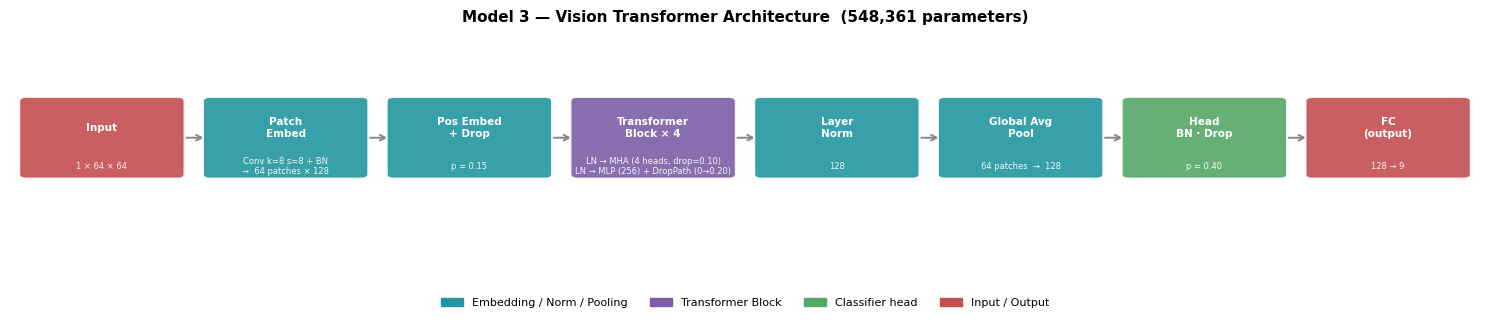

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ------------------------------------------------------------------
# Layer definitions  (label, sublabel, color)
# ------------------------------------------------------------------
SPEC  = '#C44E52'   # red    — input / output
EMBED = '#2196A0'   # teal   — embedding / norm / pooling
BLOCK = '#7B5EA7'   # purple — transformer blocks
FC    = '#55A868'   # green  — classifier head

blocks = [
    # label                sub-label                                      color
    ('Input',              '1 × 64 × 64',                                 SPEC),
    ('Patch\nEmbed',       'Conv k=8 s=8 + BN\n→  64 patches × 128',     EMBED),
    ('Pos Embed\n+ Drop',  'p = 0.15',                                    EMBED),
    ('Transformer\nBlock × 4',
                           'LN → MHA (4 heads, drop=0.10)\n'
                           'LN → MLP (256) + DropPath (0→0.20)',          BLOCK),
    ('Layer\nNorm',        '128',                                          EMBED),
    ('Global Avg\nPool',   '64 patches  →  128',                          EMBED),
    ('Head\nBN · Drop',    'p = 0.40',                                    FC),
    ('FC\n(output)',        '128 → 9',                                     SPEC),
]

fig, ax = plt.subplots(figsize=(15, 3.6))
ax.set_xlim(-0.5, len(blocks) - 0.5)
ax.set_ylim(-1, 1)
ax.axis('off')

BOX_W, BOX_H = 0.82, 0.72

for i, (label, sub, color) in enumerate(blocks):
    x = i
    rect = mpatches.FancyBboxPatch(
        (x - BOX_W / 2, -BOX_H / 2), BOX_W, BOX_H,
        boxstyle='round,pad=0.04',
        facecolor=color, edgecolor='white', linewidth=1.5, alpha=0.90,
        zorder=3,
    )
    ax.add_patch(rect)
    ax.text(x, 0.10, label, ha='center', va='center',
            fontsize=7.5, fontweight='bold', color='white', zorder=4,
            multialignment='center')
    ax.text(x, -0.28, sub, ha='center', va='center',
            fontsize=6.0, color='white', alpha=0.92, zorder=4,
            multialignment='center')

    if i < len(blocks) - 1:
        ax.annotate('', xy=(i + 1 - BOX_W / 2 - 0.02, 0),
                    xytext=(i + BOX_W / 2 + 0.02, 0),
                    arrowprops=dict(arrowstyle='->', color='#888888', lw=1.4),
                    zorder=2)

legend_items = [
    mpatches.Patch(color=EMBED, label='Embedding / Norm / Pooling'),
    mpatches.Patch(color=BLOCK, label='Transformer Block'),
    mpatches.Patch(color=FC,    label='Classifier head'),
    mpatches.Patch(color=SPEC,  label='Input / Output'),
]
ax.legend(handles=legend_items, loc='lower center',
          bbox_to_anchor=(0.5, -0.38), ncol=4, frameon=False, fontsize=8)

ax.set_title('Model 3 — Vision Transformer Architecture  (548,361 parameters)',
             fontsize=11, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

## 7. Train Model 3

In [9]:
import time

EPOCHS       = 15
LR           = 3e-4
WEIGHT_DECAY = 0.1     

model3 = Model3(num_classes=NUM_CLASSES).to(device)

with torch.no_grad():
    out = model3(xb.to(device))
print(f"forward output: {tuple(out.shape)}  (expected ({BATCH_SIZE}, {NUM_CLASSES}))")

optimizer = torch.optim.AdamW(model3.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)


def run_epoch(model, loader, train: bool):
    model.train(train)
    total_loss = 0.0
    total_correct = 0
    total_seen = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss    += loss.item() * yb.size(0)
            total_correct += (logits.argmax(1) == yb).sum().item()
            total_seen    += yb.size(0)
    return total_loss / total_seen, total_correct / total_seen


history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(model3, train_loader, train=True)
    va_loss, va_acc = run_epoch(model3, val_loader,   train=False)
    scheduler.step()
    history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss);   history['val_acc'].append(va_acc)
    print(f"epoch {epoch:2d} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.4f} | "
          f"lr {scheduler.get_last_lr()[0]:.2e} | "
          f"{time.time()-t0:.1f}s")

forward output: (64, 9)  (expected (64, 9))
epoch  1 | train loss 1.0665 acc 0.7403 | val loss 0.7476 acc 0.8964 | lr 2.97e-04 | 39.0s
epoch  2 | train loss 0.8604 acc 0.8346 | val loss 0.7380 acc 0.8944 | lr 2.87e-04 | 38.1s
epoch  3 | train loss 0.8071 acc 0.8581 | val loss 0.8066 acc 0.8617 | lr 2.71e-04 | 38.2s
epoch  4 | train loss 0.7740 acc 0.8734 | val loss 0.8385 acc 0.8519 | lr 2.50e-04 | 38.2s
epoch  5 | train loss 0.7489 acc 0.8847 | val loss 0.6799 acc 0.9195 | lr 2.25e-04 | 38.6s
epoch  6 | train loss 0.7306 acc 0.8932 | val loss 0.8393 acc 0.8507 | lr 1.96e-04 | 39.0s
epoch  7 | train loss 0.7132 acc 0.9014 | val loss 0.8150 acc 0.8599 | lr 1.66e-04 | 39.2s
epoch  8 | train loss 0.6988 acc 0.9090 | val loss 0.6642 acc 0.9323 | lr 1.34e-04 | 39.3s
epoch  9 | train loss 0.6861 acc 0.9146 | val loss 0.7427 acc 0.8959 | lr 1.04e-04 | 39.2s
epoch 10 | train loss 0.6729 acc 0.9211 | val loss 0.6952 acc 0.9138 | lr 7.50e-05 | 39.1s
epoch 11 | train loss 0.6637 acc 0.9262 | val 

## 8. Evaluate Model 3 on the test set

In [10]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score, cohen_kappa_score,
)


@torch.no_grad()
def collect_predictions(model, loader):
    model.eval()
    ys, ps = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        ps.append(model(xb).argmax(1).cpu().numpy())
        ys.append(yb.numpy())
    return np.concatenate(ys), np.concatenate(ps)


y_true, y_pred = collect_predictions(model3, test_loader)
target_names = [idx_to_class[i] for i in range(NUM_CLASSES)]

print(f"Test samples: {len(y_true):,}")
print(f"\nAccuracy:           {accuracy_score(y_true, y_pred):.4f}")
print(f"Balanced accuracy:  {balanced_accuracy_score(y_true, y_pred):.4f}  (mean per-class recall)")
print(f"Cohen's kappa:      {cohen_kappa_score(y_true, y_pred):.4f}")
for avg in ('macro', 'weighted'):
    p = precision_score(y_true, y_pred, average=avg, zero_division=0)
    r = recall_score(   y_true, y_pred, average=avg, zero_division=0)
    f = f1_score(       y_true, y_pred, average=avg, zero_division=0)
    print(f"{avg:>8s}: precision {p:.4f}  recall {r:.4f}  f1 {f:.4f}")

print("\nPer-class report:")
print(classification_report(y_true, y_pred, target_names=target_names,
                            digits=4, zero_division=0))

# Confusion matrix as a labeled DataFrame (rows = true, columns = predicted)
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)
print("Confusion matrix (rows=true, cols=predicted):")
cm_df

Test samples: 34,590

Accuracy:           0.9167
Balanced accuracy:  0.8503  (mean per-class recall)
Cohen's kappa:      0.7380
   macro: precision 0.6834  recall 0.8503  f1 0.7400
weighted: precision 0.9524  recall 0.9167  f1 0.9306

Per-class report:
              precision    recall  f1-score   support

      Center     0.6903    0.9627    0.8041       859
       Donut     0.6715    0.8288    0.7419       111
    Edge-Loc     0.5808    0.8314    0.6838      1038
   Edge-Ring     0.9576    0.9566    0.9571      1936
         Loc     0.4754    0.7256    0.5744       718
   Near-full     0.8286    0.9667    0.8923        30
      Random     0.8192    0.8382    0.8286       173
     Scratch     0.1343    0.6192    0.2207       239
        none     0.9930    0.9236    0.9570     29486

    accuracy                         0.9167     34590
   macro avg     0.6834    0.8503    0.7400     34590
weighted avg     0.9524    0.9167    0.9306     34590

Confusion matrix (rows=true, cols=predicte

,Center,Donut,Edge-Loc,Edge-Ring,Loc,Near-full,Random,Scratch,none
Center,827,3,1,0,11,0,0,2,15
Donut,2,92,1,0,14,0,2,0,0
Edge-Loc,5,1,863,14,64,0,4,26,61
Edge-Ring,5,0,58,1852,1,0,0,5,15
Loc,19,25,31,0,521,0,4,61,57
Near-full,1,0,0,0,0,29,0,0,0
Random,6,4,5,0,5,6,145,1,1
Scratch,4,4,6,0,32,0,1,148,44
none,329,8,521,68,448,0,21,859,27232
